In [1]:
import numpy as np
import torch
import matplotlib
from matplotlib import pyplot as plt
from matplotlib import ticker

import scipy as sc

from generator import GeneratorBuilder
from potential import Polymer
from aimmd import AIMMDNetwork, AIMMDCommittorTrainer
from util import ress, correlate
from tps import load_umbrella_sampling_samples, generate_path_to_state_brownian

from transform_layers import PolymerTransformLayer, PolymerNormLayer

import json
from tqdm.auto import tqdm

import os

TO_CM = 1/2.54
matplotlib.rcParams.update({'font.size': 10})
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 10
})

In [2]:
potential = Polymer(7, 2)

trainer = torch.load("trainers/polymer.pt", weights_only=False)

generator = trainer.generator
aimmd_network = trainer.aimmd_network

beta = 10.0

example_bias_center = 0.0

def propose(n_samples):
    z_samples = generator.generate_z_samples(n_samples, betas=beta)
    z_samples = torch.hstack([z_samples, z_samples.new_ones((n_samples, 1))*example_bias_center])

    with torch.inference_mode():
        samples, log_R_zx = generator.F_zx(z_samples)

        valid = generator.get_weights(samples, log_R_zx, z_samples, beta=beta, normalize=True, drop_invalid_samples=True) > 0

        log_weights = (-generator.potential.evaluate(samples)*beta
                       + beta/generator.reference_beta/(2*generator.normal_std**2)*torch.norm(z_samples[..., :generator.dimensions], dim=-1)**2
                       + log_R_zx)
        log_weights[~valid] = -torch.inf

        Polymer.mirror(samples[:, :-1], probability=0.5, in_place=True) # Restore the mirror symmetry

    return samples, log_weights.double().cpu().numpy()


def fit_pareto_tail(exceedances):
    n = len(exceedances)
    m = 30 + int(n**0.5)

    b = 1 - np.sqrt(m/(np.arange(1, m + 1, dtype=float) - 0.5))
    b /= 3*exceedances[int(n/4 + 0.5) - 1]
    b += 1/exceedances[-1]

    k = np.log1p(-b[:, None]*exceedances).mean(axis=-1)
    length = n*(np.log(-(b/k)) - k - 1)

    with np.errstate(over='ignore'):
        weights = 1/np.exp(length - length[:, None]).sum(axis=-1)

    keep = weights >= 10*np.finfo(float).eps
    weights, b = weights[keep]/np.sum(weights[keep]), b[keep]

    b_posterior = np.sum(b*weights)
    k_posterior = np.log1p(-b_posterior*exceedances).mean()
    k_posterior = (n*k_posterior + 10*0.5)/(n + 10)

    return k_posterior, -k_posterior/b_posterior


def pareto_smooth(weights):
    smoothed = weights.copy()
    finite = np.flatnonzero(weights > 0)

    order = finite[np.argsort(weights[finite])]
    n_tail = int(min(0.2*len(order), 3*np.sqrt(len(order))))

    if n_tail < 10:
        return smoothed, np.inf

    tail, cutoff = order[-n_tail:], weights[order[-n_tail - 1]]

    k_hat, sigma = fit_pareto_tail(weights[tail] - cutoff)

    quantiles = (np.arange(1, n_tail + 1) - 0.5)/n_tail
    if np.abs(k_hat) > 1e-10:
        smoothed[tail] = cutoff + sigma*np.expm1(-k_hat*np.log1p(-quantiles))/k_hat
    else:
        smoothed[tail] = cutoff - sigma*np.log1p(-quantiles)

    smoothed[tail] = np.minimum(smoothed[tail], weights[order[-1]])

    return smoothed, k_hat

In [ ]:
N_ADAPTATION_ROUNDS = 500
ADAPTATION_BATCH_SIZE = 500_000
TRAINING_BATCH_SIZE = 256
N_TRAINING_SAMPLES = 80*TRAINING_BATCH_SIZE
TRAINING_EPOCHS = 5
TRAINING_LR = 1e-5

for adaptation_round in range(1, N_ADAPTATION_ROUNDS + 1):
    samples, log_weights = propose(ADAPTATION_BATCH_SIZE)

    weights = np.exp(log_weights - np.max(log_weights))
    smoothed_weights, k_hat = pareto_smooth(weights)

    relative_ess = np.sum(smoothed_weights)**2/(np.sum(smoothed_weights**2)*len(smoothed_weights))

    chosen_indices = np.random.choice(len(smoothed_weights), N_TRAINING_SAMPLES, p=smoothed_weights/np.sum(smoothed_weights))

    training_samples = torch.tensor(samples[torch.from_numpy(chosen_indices)].cpu().numpy(), dtype=torch.float32, device=generator.device)

    generator.train(TRAINING_BATCH_SIZE, x_samples=training_samples, epochs=TRAINING_EPOCHS, lr=TRAINING_LR,
                    w_KL=0.0, w_ML=1.0, n_out=0, push_to_gpu=generator.device == "cuda", x_sample_betas=beta)

    print(f"round {adaptation_round}: k_hat = {k_hat:.2f}, relative ESS = {relative_ess:.2e} "
          f"({relative_ess*ADAPTATION_BATCH_SIZE:.0f} of {ADAPTATION_BATCH_SIZE} proposals)")

torch.save(trainer, "trainers/polymer_adapted.pt")

In [ ]:
potential = Polymer(7, 2)

trainer = torch.load("trainers/polymer_adapted.pt", weights_only=False)

generator = trainer.generator
aimmd_network = trainer.aimmd_network

N_REPEATS = 30
N_SPS = 10_000
PROPOSE_SIZE = 5_000_000

for repeat in tqdm(range(1, N_REPEATS+1)):
    generated_sps, log_weights = propose(PROPOSE_SIZE)

    max_log_weight = np.max(log_weights)
    weights = np.exp(log_weights - max_log_weight)

    chosen_indices = np.random.choice(len(weights), N_SPS, p=weights/np.sum(weights))
    resampled_sps = generated_sps[torch.from_numpy(chosen_indices)].detach().cpu().numpy()

    np.savetxt(f"polymer_tps_generated/resampled_sps_{repeat}.csv", resampled_sps[:, :-1], delimiter=',')

  0%|          | 0/30 [00:00<?, ?it/s]

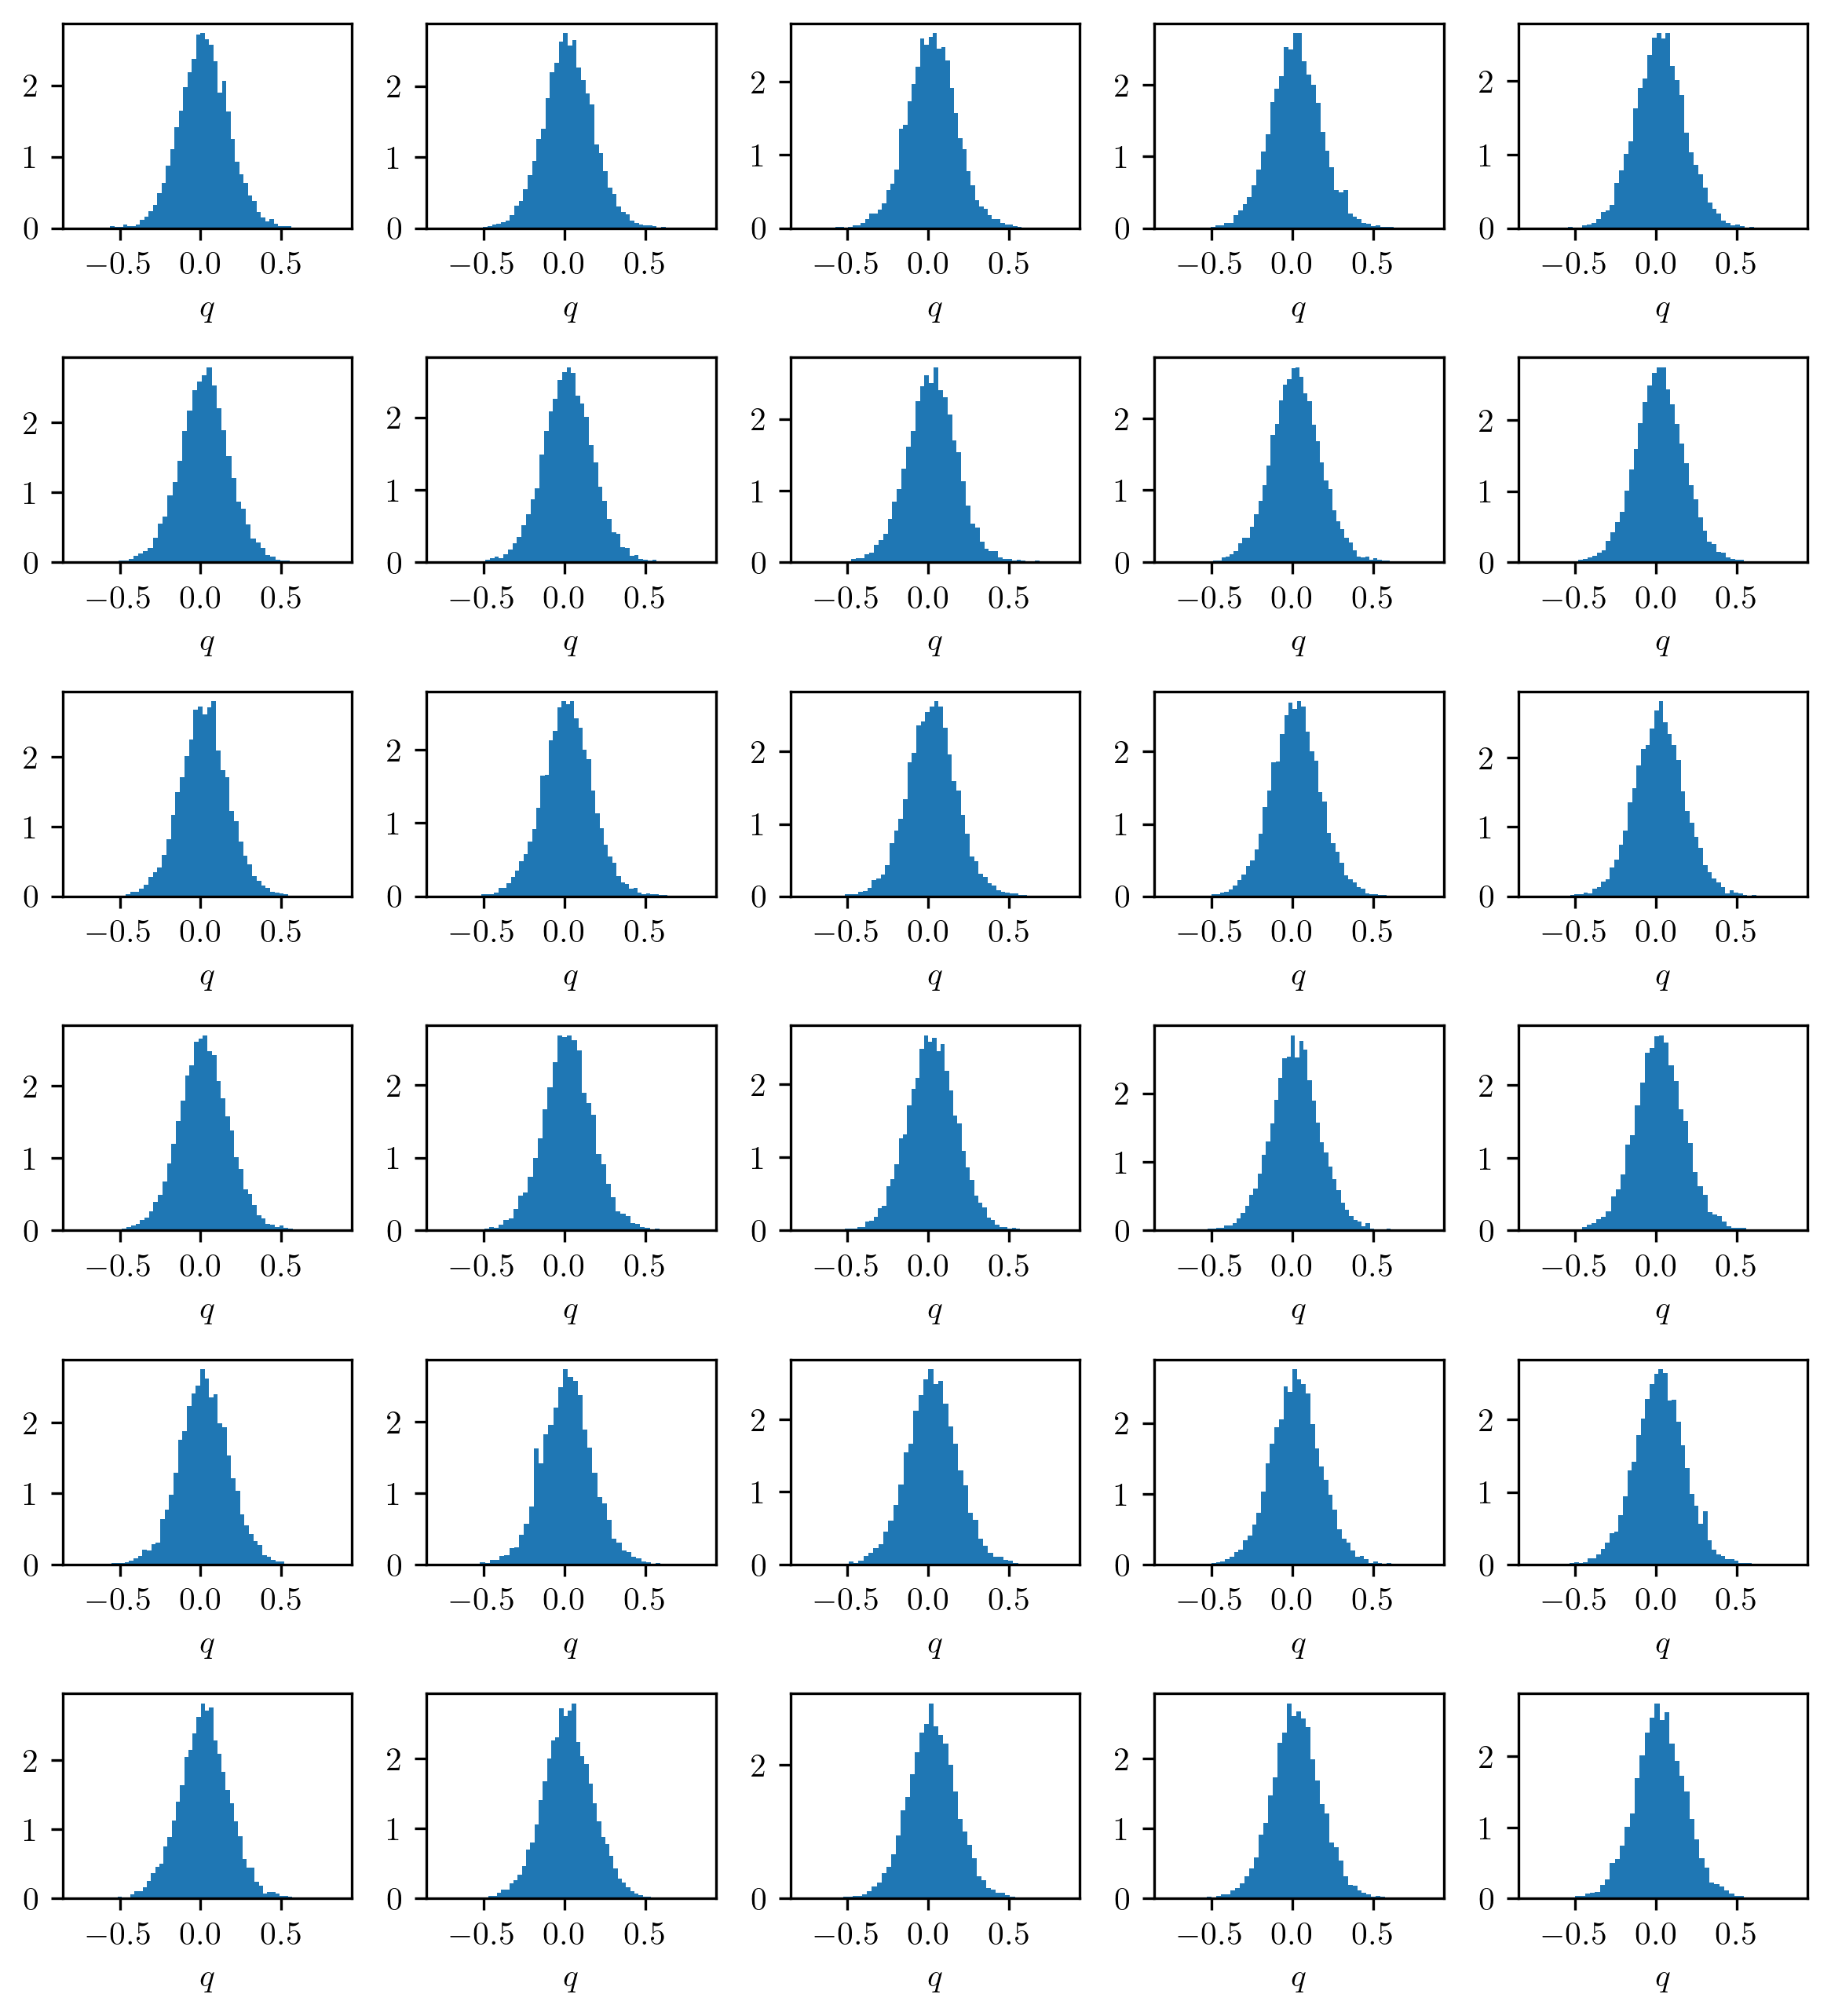

In [5]:
n_files = 30

potential = Polymer(7, 2)

trainer = torch.load("trainers/polymer_adapted.pt", weights_only=False)

generator = trainer.generator
aimmd_network = trainer.aimmd_network

fig, ax = plt.subplots(6, 5, figsize=(20*TO_CM, 22*TO_CM), dpi=300)

ax = ax.flatten()

for repeat in tqdm(range(1, n_files+1)):
    sps = np.loadtxt(f"polymer_tps_generated/resampled_sps_{repeat}.csv", delimiter=',')
    sps = Polymer.constrain_first_angle_cartesian(sps)

    q = aimmd_network(torch.tensor(sps, dtype=torch.float32, device="cuda")).detach().cpu().numpy().flatten()

    ax[repeat-1].hist(q, density=True, bins=50)
    ax[repeat-1].sharex(ax[0])
    ax[repeat-1].set_xlabel("$q$")

fig.tight_layout()

plt.show()

In [3]:
print("Run polymer_tps_comparison_generated_paths.py to generate the transition paths from these shooting points in parallel and save them.")

Run polymer_tps_comparison_generated_paths.py to generate the transition paths from these shooting points in parallel and save them.


# Abs. error of $p(x | TP)$

In [ ]:
import sys
!{sys.executable} -m analysis.run class_counts --fold

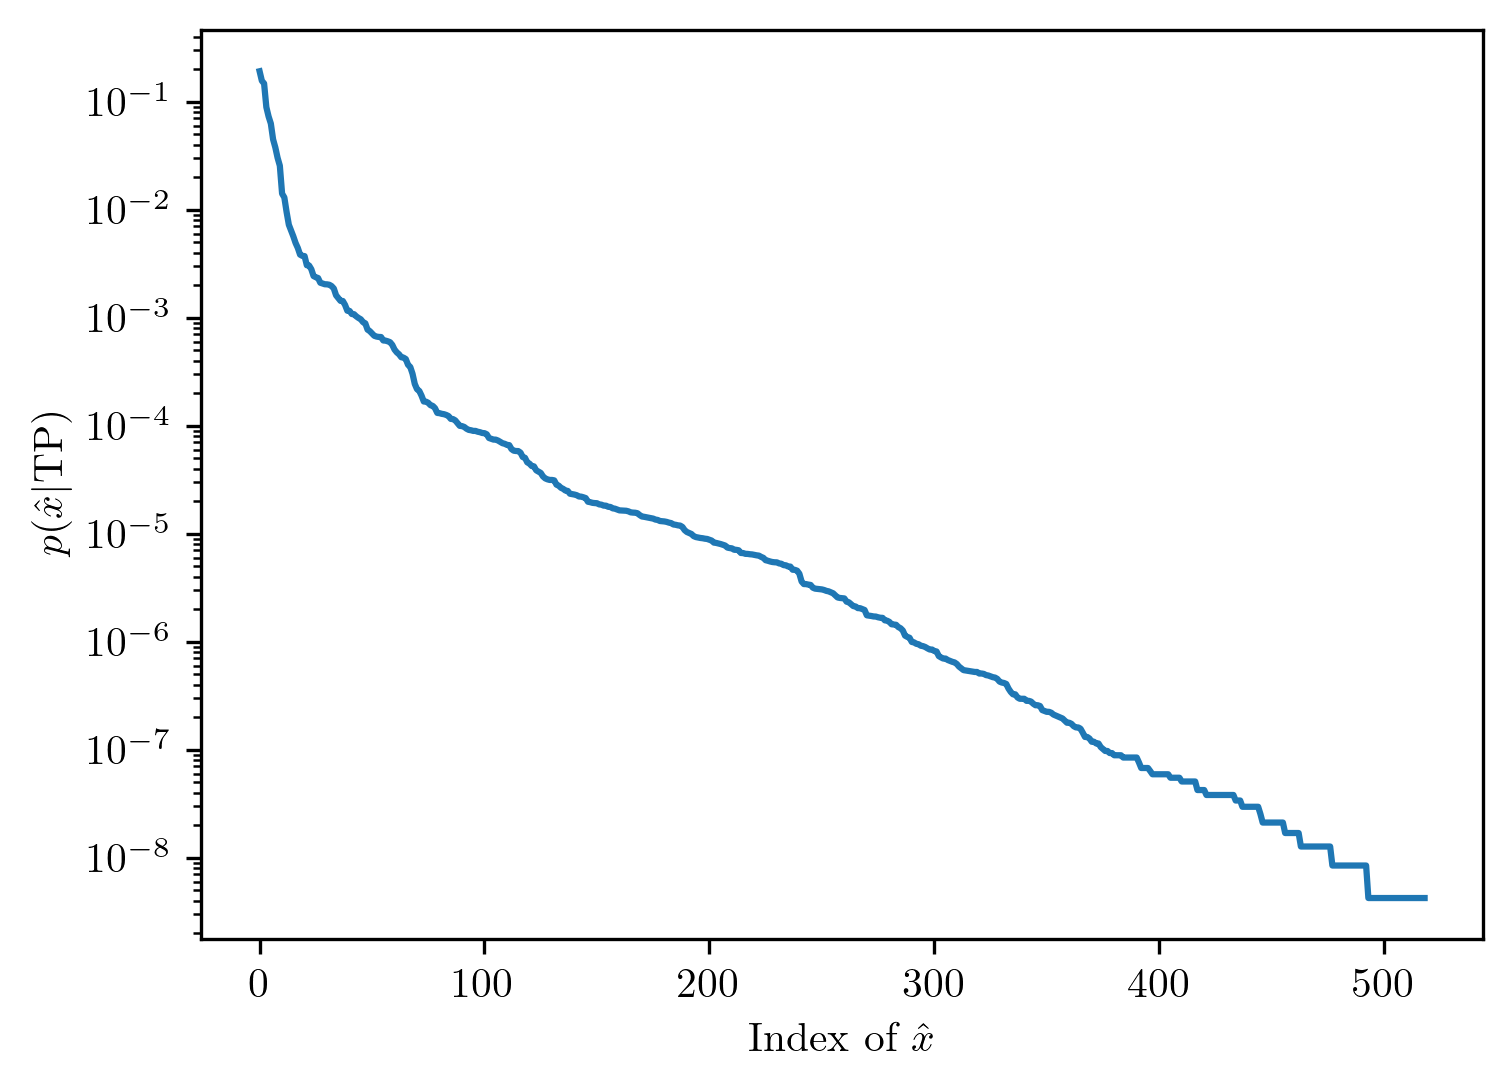

10102.0


In [6]:
reference_class_counts = np.loadtxt("polymer_tps_reference/reference_class_counts_folded.csv", delimiter=',')

reference_p_x_TP = reference_class_counts
reference_p_x_TP[:, 1] /= np.sum(reference_class_counts[:, 1])

sort_indices = np.argsort(reference_class_counts[:, 1])[::-1]
reference_p_x_TP = reference_p_x_TP[sort_indices]

fig, ax = plt.subplots(1, 1, figsize=(14*TO_CM, 10*TO_CM), dpi=300)

ax.plot(reference_p_x_TP[reference_p_x_TP[:, 1] > 0][:, 1])

ax.set_xlabel(r"Index of $\hat{x}$")
ax.set_ylabel(r"$p(\hat{x} | \mathrm{TP})$")

ax.set_yscale('log')

plt.show()

print(reference_p_x_TP[0, 0])

sort_indices = np.argsort(reference_p_x_TP[:, 0])
reference_p_x_TP = reference_p_x_TP[sort_indices]

In [ ]:
import sys
!{sys.executable} -m analysis.run errors --datasets normal --fold

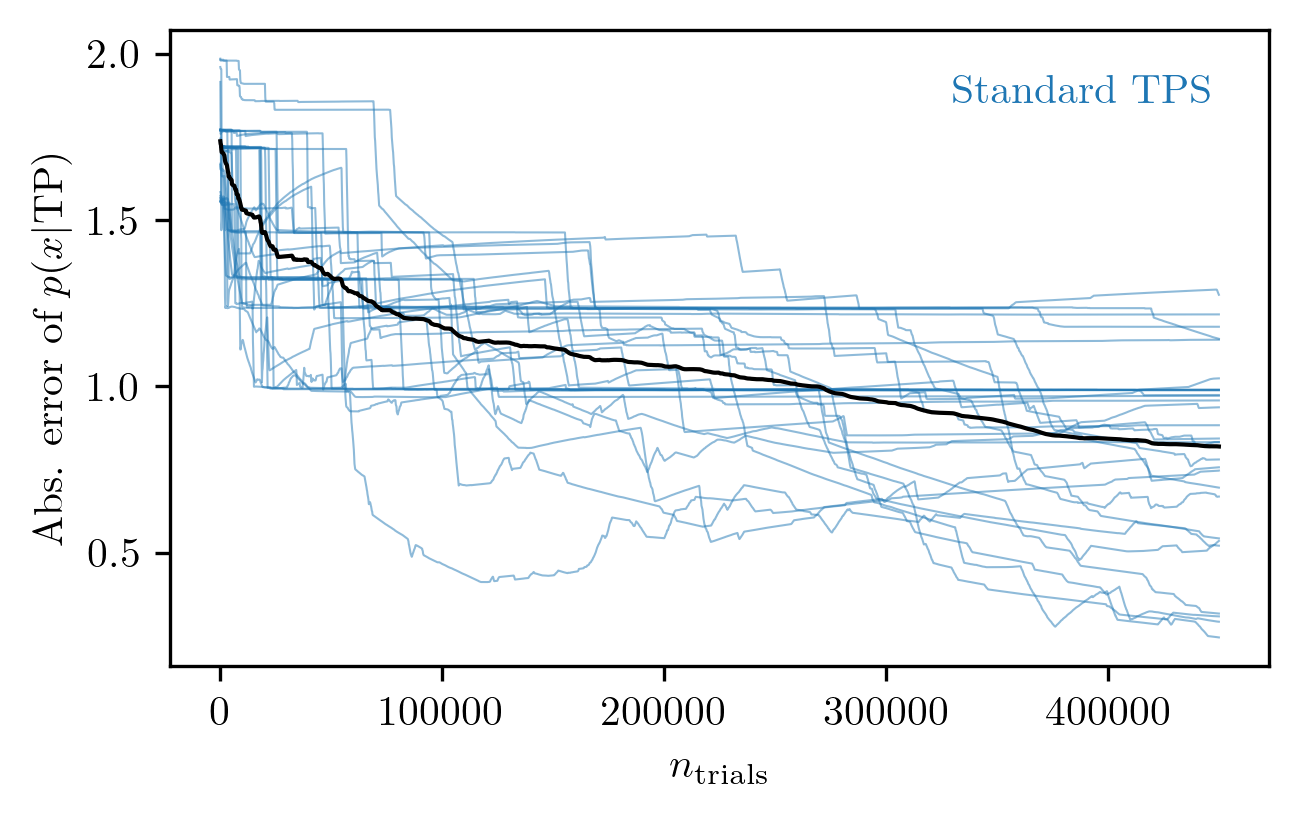

In [7]:
all_errors = np.loadtxt("polymer_tps_normal/errors_folded.csv", delimiter=",")

fig, ax = plt.subplots(1, 1, figsize=(12*TO_CM, 7*TO_CM), dpi=300)

x = np.arange(150, 450_000 + 150, 150)

for error in all_errors:
    ax.plot(x, error, color=matplotlib.rcParams['axes.prop_cycle'].by_key()['color'][0], alpha=0.5, linewidth=0.5)

mean_errors = np.mean(all_errors, axis=0)
ax.plot(x, mean_errors, color="black", linewidth=1)

ax.set_xlabel(r"$n_{\mathrm{trials}}$")
ax.set_ylabel(r"Abs. error of $p(x | \mathrm{TP})$")

ax.text(0.95, 0.9, f"Standard TPS", horizontalalignment='right', verticalalignment='center', transform=ax.transAxes, color=matplotlib.rcParams['axes.prop_cycle'].by_key()['color'][0])

plt.show()

In [ ]:
import sys
!{sys.executable} -m analysis.run errors --datasets generated --fold

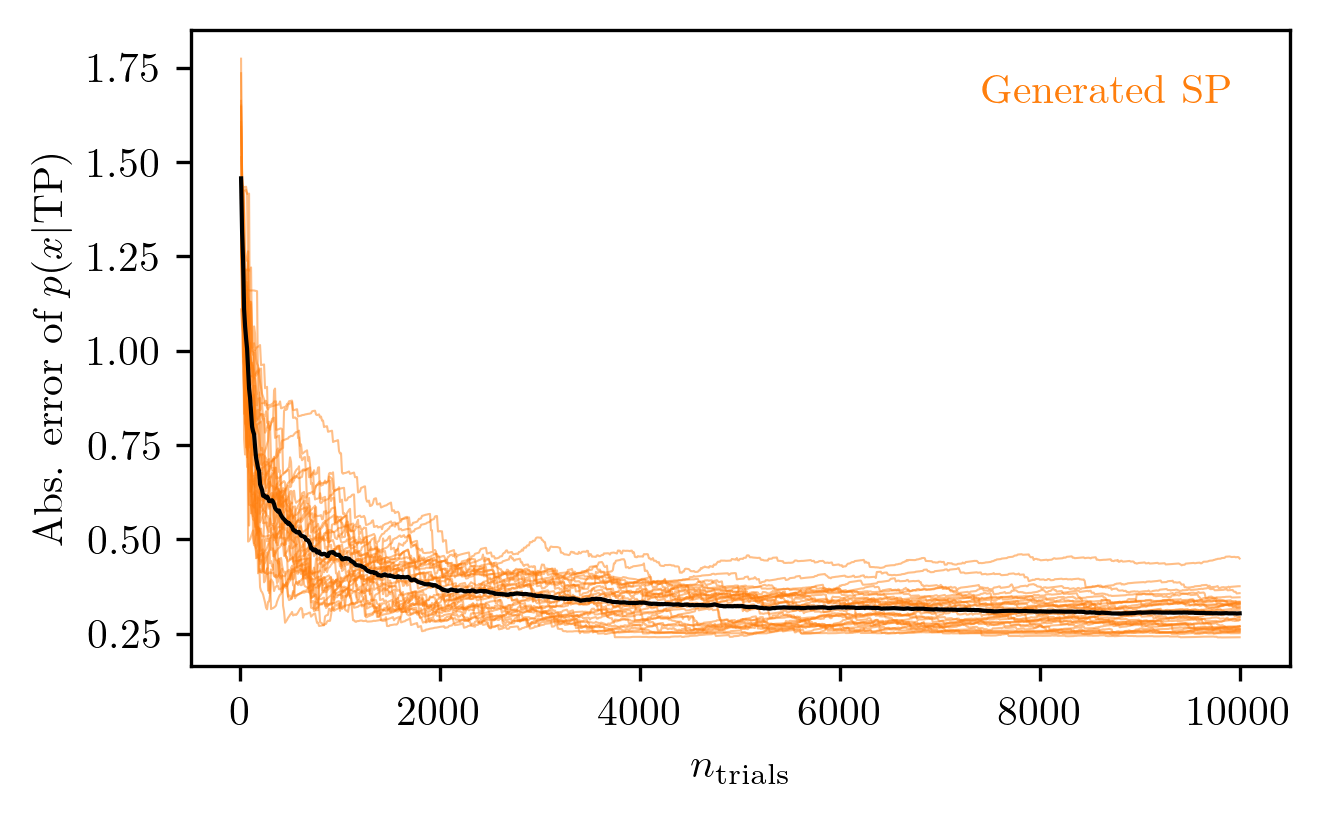

In [8]:
all_errors = np.loadtxt("polymer_tps_generated/errors_folded.csv", delimiter=",")

fig, ax = plt.subplots(1, 1, figsize=(12*TO_CM, 7*TO_CM), dpi=300)

x = np.arange(10, 10_000 + 10, 10)

for error in all_errors:
    ax.plot(x, error, color=matplotlib.rcParams['axes.prop_cycle'].by_key()['color'][1], alpha=0.5, linewidth=0.5)

mean_errors = np.mean(all_errors, axis=0)
ax.plot(x, mean_errors, color="black", linewidth=1)

ax.set_xlabel(r"$n_{\mathrm{trials}}$")
ax.set_ylabel(r"Abs. error of $p(x | \mathrm{TP})$")

ax.text(0.95, 0.9, f"Generated SP", horizontalalignment='right', verticalalignment='center', transform=ax.transAxes, color=matplotlib.rcParams['axes.prop_cycle'].by_key()['color'][1])

plt.show()

# Path length $\bar{\tau}(n)$

In [ ]:
import sys
!{sys.executable} -m analysis.run path_lengths --datasets reference

In [ ]:
import sys
!{sys.executable} -m analysis.run path_lengths --datasets normal

In [ ]:
import sys
!{sys.executable} -m analysis.run path_lengths --datasets generated

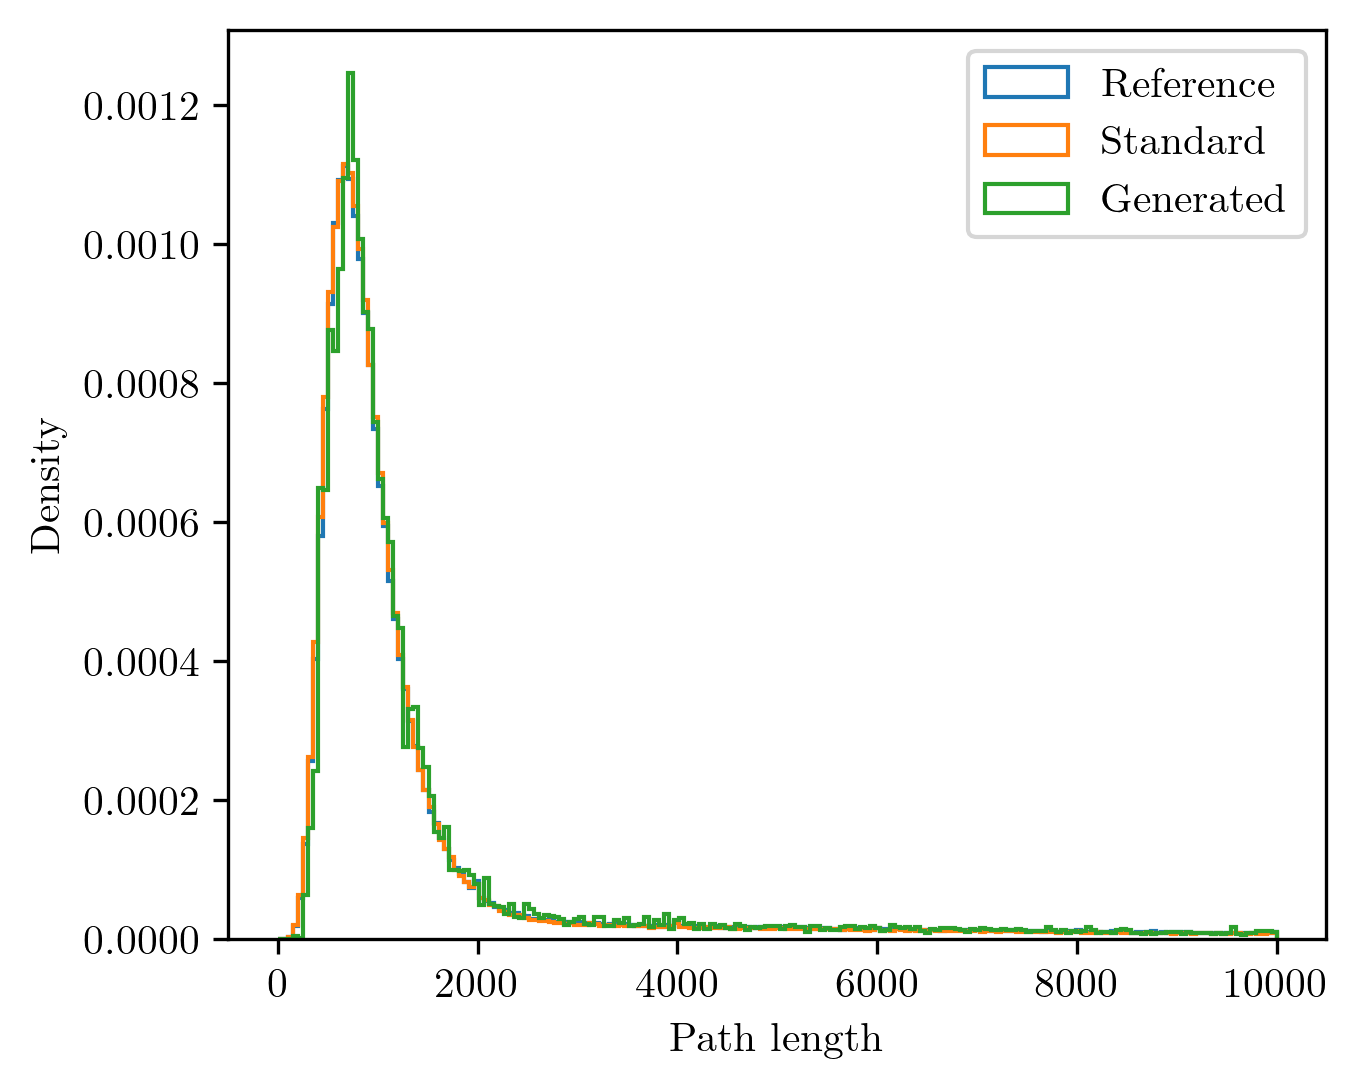

In [9]:
reference_path_lengths = np.loadtxt("polymer_tps_reference/path_lengths.csv", delimiter=',').flatten()
normal_path_lengths = np.loadtxt("polymer_tps_normal/path_lengths.csv", delimiter=',').flatten()
generated_path_lengths = np.loadtxt("polymer_tps_generated/path_lengths.csv", delimiter=',')

generated_path_weights = []

for i in range(1, generated_path_lengths.shape[0] + 1):
    generated_path_weights += np.loadtxt(f"polymer_tps_generated/path_weights_{i}.csv", delimiter=',').tolist()

generated_path_lengths = generated_path_lengths.flatten()

bins = np.linspace(0, 10000, 200)

fig, ax = plt.subplots(1, 1, figsize=(12*TO_CM, 10*TO_CM), dpi=300)

ax.hist(reference_path_lengths, label="Reference", histtype="step", bins=bins, density=True)
ax.hist(normal_path_lengths, label="Standard", histtype="step", bins=bins, density=True)
ax.hist(generated_path_lengths, weights=generated_path_weights, label="Generated", histtype="step", bins=bins, density=True)

ax.set_xlabel("Path length")
ax.set_ylabel("Density")

ax.legend()

plt.show()

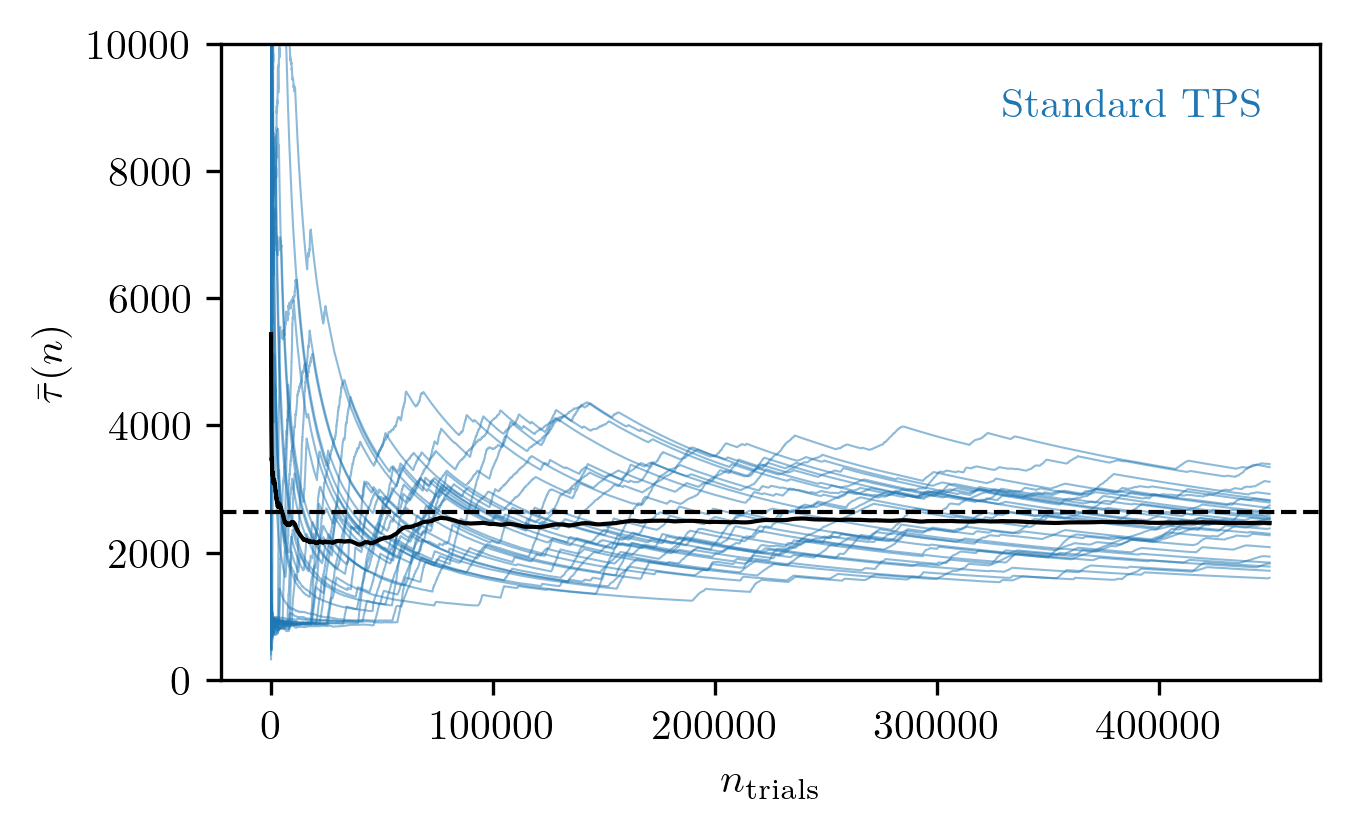

In [10]:
normal_path_lengths = np.loadtxt("polymer_tps_normal/path_lengths.csv", delimiter=',')

mean_path_lengths = np.cumsum(normal_path_lengths, axis=-1)/np.arange(1, normal_path_lengths.shape[-1]+1)

fig, ax = plt.subplots(1, 1, figsize=(12*TO_CM, 7*TO_CM), dpi=300)

x = np.arange(15, 450_000 + 15, 15)

for mean_path_length in mean_path_lengths:
    ax.plot(x, mean_path_length, color=matplotlib.rcParams['axes.prop_cycle'].by_key()['color'][0], alpha=0.5, linewidth=0.5)

mean_mean_gs = np.mean(mean_path_lengths, axis=0)
ax.plot(x, mean_mean_gs, color="black", linewidth=1)

reference_path_lengths = np.loadtxt("polymer_tps_reference/path_lengths.csv", delimiter=',')

ax.axhline(y=np.mean(reference_path_lengths), linewidth=1.0, ls='dashed', color="black")

ax.set_xlabel(r"$n_{\mathrm{trials}}$")
ax.set_ylabel(r"$\bar{\tau}(n)$")

ax.text(0.95, 0.9, f"Standard TPS", horizontalalignment='right', verticalalignment='center', transform=ax.transAxes, color=matplotlib.rcParams['axes.prop_cycle'].by_key()['color'][0])

ax.set_ylim((-10, 10_000))

plt.show()

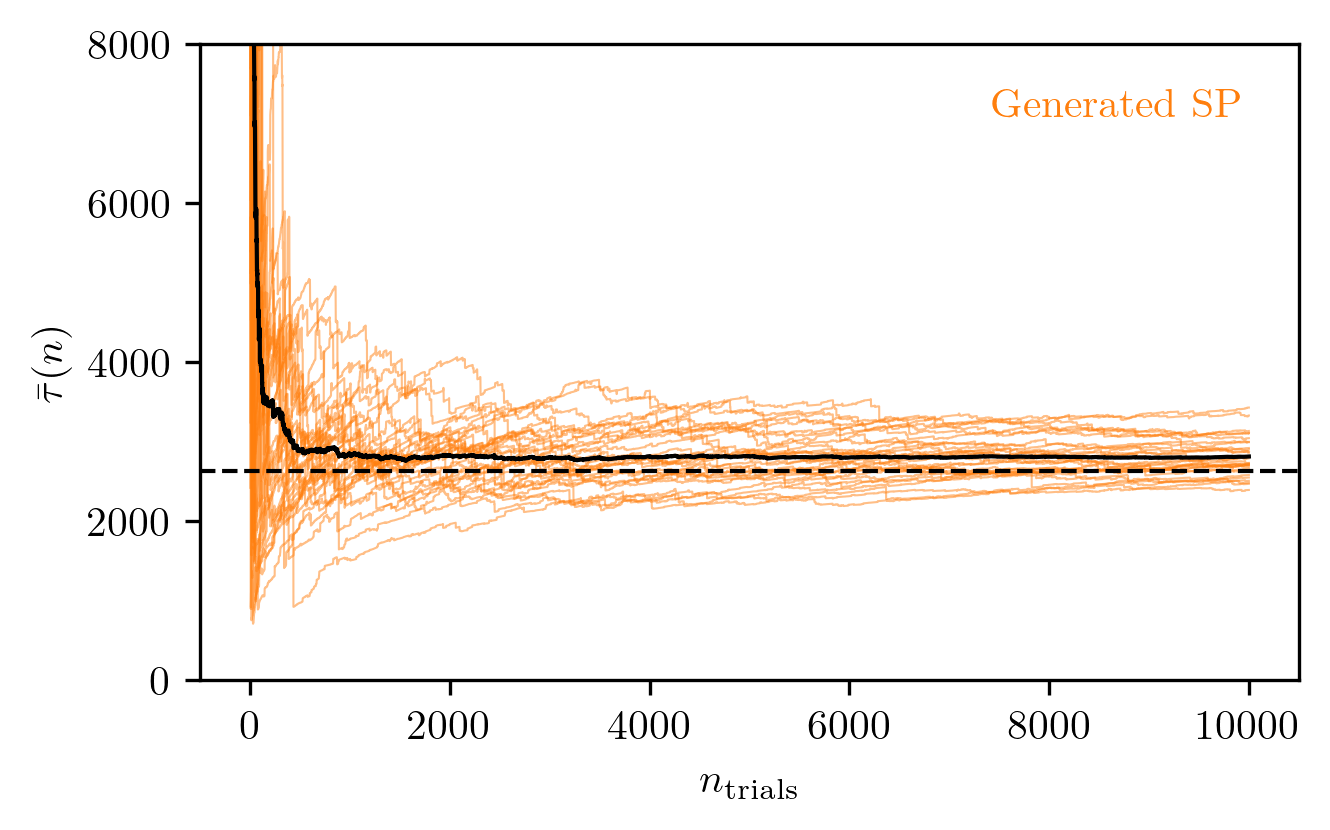

In [11]:
generated_path_lengths = np.loadtxt("polymer_tps_generated/path_lengths.csv", delimiter=',')
generated_path_weights = []

for i in range(1, generated_path_lengths.shape[0] + 1):
    generated_path_weights.append(np.loadtxt(f"polymer_tps_generated/path_weights_{i}.csv", delimiter=','))

generated_path_weights = np.array(generated_path_weights)

mean_path_lengths = np.cumsum(generated_path_lengths*generated_path_weights, axis=1)/np.cumsum(generated_path_weights, axis=1)

fig, ax = plt.subplots(1, 1, figsize=(12*TO_CM, 7*TO_CM), dpi=300)

x = np.arange(1, 10_000 + 1, 1)

for mean_path_length in mean_path_lengths:
    ax.plot(x, mean_path_length, color=matplotlib.rcParams['axes.prop_cycle'].by_key()['color'][1], alpha=0.5, linewidth=0.5)

mean_mean_path_lengths = np.mean(mean_path_lengths, axis=0)
ax.plot(x, mean_mean_path_lengths, color="black", linewidth=1)

reference_path_lengths = np.loadtxt("polymer_tps_reference/path_lengths.csv", delimiter=',')

ax.axhline(y=np.mean(reference_path_lengths), linewidth=1.0, ls='dashed', color="black")

ax.set_xlabel(r"$n_{\mathrm{trials}}$")
ax.set_ylabel(r"$\bar{\tau}(n)$")

ax.set_ylim((0, 8_000))

ax.text(0.95, 0.9, f"Generated SP", horizontalalignment='right', verticalalignment='center', transform=ax.transAxes, color=matplotlib.rcParams['axes.prop_cycle'].by_key()['color'][1])

plt.show()

# Correlation function $C_{\tau(X)}(k)$

In [ ]:
import sys
!{sys.executable} -m analysis.run correlations --datasets normal

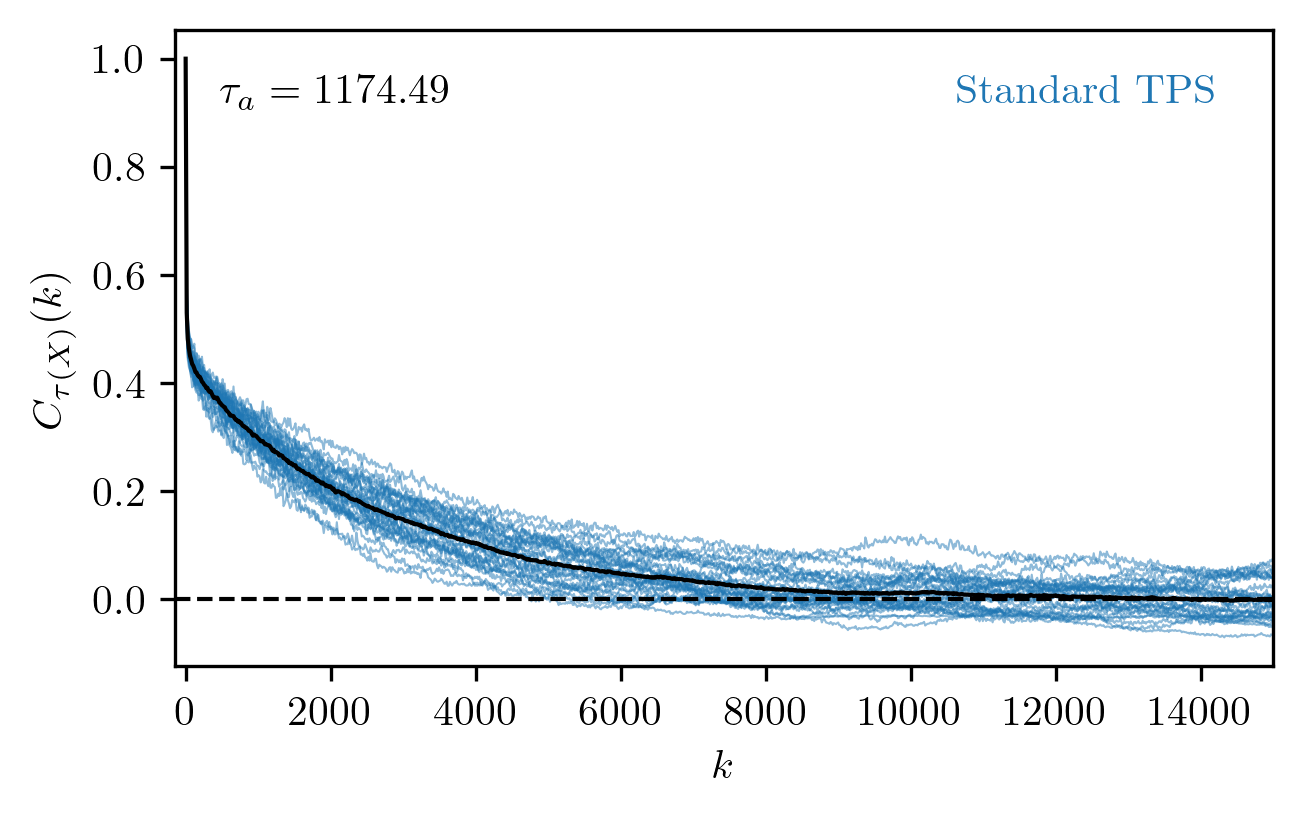

In [12]:
M = 1000
TRIALS_PER_SAMPLE = 15

correlation_functions = np.loadtxt("polymer_tps_normal/correlation_function_path_lengths.csv", delimiter=",")

k = np.arange(M)*TRIALS_PER_SAMPLE

fig, ax = plt.subplots(1, 1, figsize=(12*TO_CM, 7*TO_CM), dpi=300)

for correlation_function in correlation_functions:
    ax.plot(k, correlation_function[:M], color=matplotlib.rcParams['axes.prop_cycle'].by_key()['color'][0], alpha=0.5, linewidth=0.5)

mean_correlation_function = np.mean(correlation_functions, axis=0)

autocorrelation_time = (0.5 + np.sum(mean_correlation_function[1:M+1]))*TRIALS_PER_SAMPLE

ax.plot(k, mean_correlation_function[:M], color="black", linewidth=1)

ax.axhline(y=0.0, linewidth=1.0, ls='dashed', color="black")

ax.set_xlabel(r"$k$")
ax.set_ylabel(r"$C_{\tau(X)}(k)$")

ax.set_xlim((-10*TRIALS_PER_SAMPLE, M*TRIALS_PER_SAMPLE))

ax.text(0.95, 0.9, f"Standard TPS", horizontalalignment='right', verticalalignment='center', transform=ax.transAxes, color=matplotlib.rcParams['axes.prop_cycle'].by_key()['color'][0])

ax.text(0.25, 0.9, r"$\tau_a = " + str(round(autocorrelation_time, 2)) + "$", horizontalalignment='right', verticalalignment='center', transform=ax.transAxes,)

plt.show()

In [ ]:
import sys
!{sys.executable} -m analysis.run correlations --datasets generated

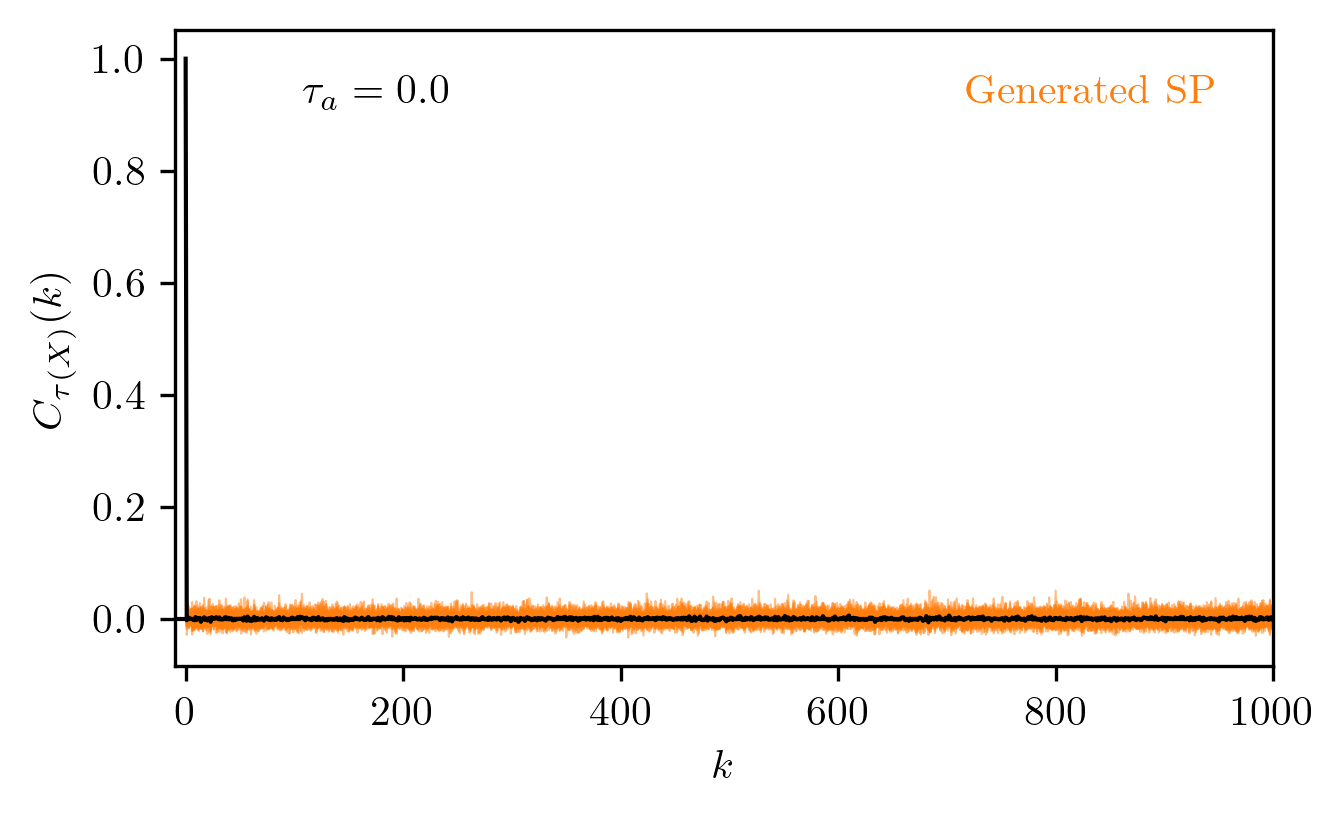

In [13]:
M = 1000

correlation_functions = np.loadtxt("polymer_tps_generated/correlation_function_path_lengths.csv", delimiter=",")

fig, ax = plt.subplots(1, 1, figsize=(12*TO_CM, 7*TO_CM), dpi=300)

for correlation_function in correlation_functions:
    ax.plot(correlation_function[:M], color=matplotlib.rcParams['axes.prop_cycle'].by_key()['color'][1], alpha=0.5, linewidth=0.5)

mean_correlation_function = np.mean(correlation_functions, axis=0)

autocorrelation_time = 0.0

ax.plot(mean_correlation_function[:M], color="black", linewidth=1)

ax.axhline(y=0.0, linewidth=1.0, ls='dashed', color="black")

ax.set_xlabel(r"$k$")
ax.set_ylabel(r"$C_{\tau(X)}(k)$")

ax.set_xlim((-10, M))

ax.text(0.95, 0.9, f"Generated SP", horizontalalignment='right', verticalalignment='center', transform=ax.transAxes, color=matplotlib.rcParams['axes.prop_cycle'].by_key()['color'][1])

ax.text(0.25, 0.9, r"$\tau_a = " + str(round(autocorrelation_time, 2)) + "$", horizontalalignment='right', verticalalignment='center', transform=ax.transAxes,)

plt.show()

# Combined plot

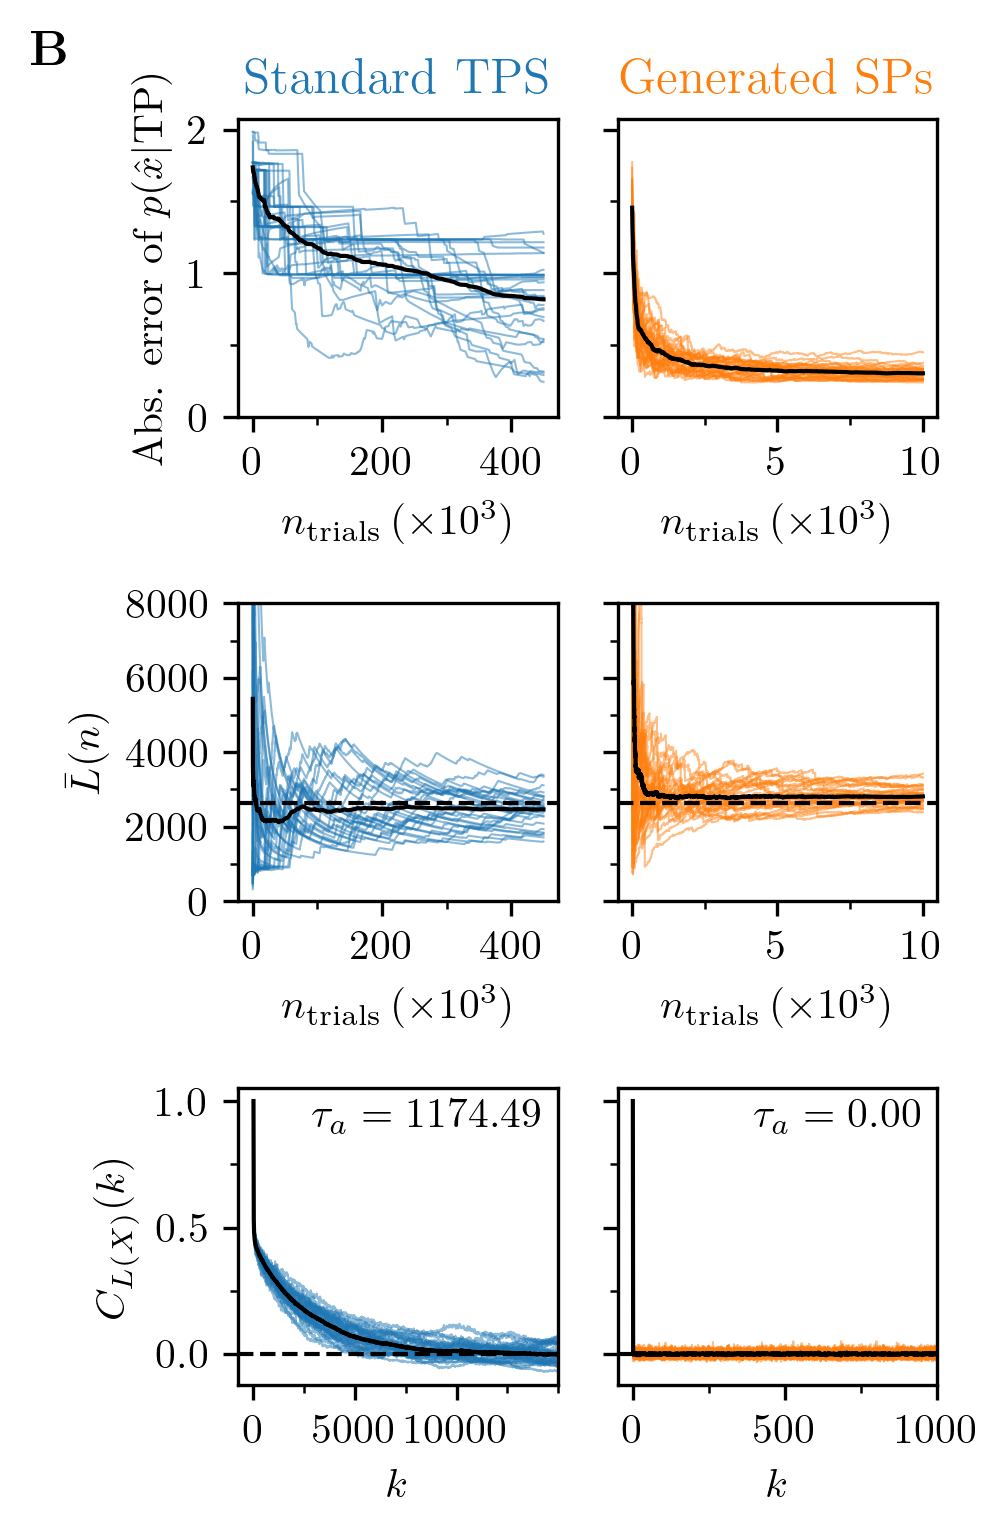

In [15]:
M = 1000

colors = matplotlib.rcParams['axes.prop_cycle'].by_key()['color']

columns = [("polymer_tps_normal", "Standard TPS", colors[0], 15),
           ("polymer_tps_generated", "Generated SPs", colors[1], 1)]

reference_path_lengths = np.loadtxt("polymer_tps_reference/path_lengths.csv", delimiter=',')
reference_mean_path_length = np.mean(reference_path_lengths)

fig, axes = plt.subplots(3, len(columns), figsize=(8.5*TO_CM, 13*TO_CM), dpi=300, sharey='row')

for column, (folder, label, color, trials_per_sample) in enumerate(columns):
    ax_error, ax_tau, ax_correlation = axes[:, column]

    ax_error.set_title(label, color=color)

    all_errors = np.loadtxt(f"{folder}/errors_folded.csv", delimiter=",")

    x = np.arange(1, all_errors.shape[-1] + 1)*10*trials_per_sample

    for error in all_errors:
        ax_error.plot(x, error, color=color, alpha=0.5, linewidth=0.5)

    mean_errors = np.mean(all_errors, axis=0)
    ax_error.plot(x, mean_errors, color="black", linewidth=1)

    ax_error.set_xlabel(r"$n_{\mathrm{trials}}$")

    path_lengths = np.loadtxt(f"{folder}/path_lengths.csv", delimiter=',')

    if folder == "polymer_tps_generated":
        path_weights = np.array([np.loadtxt(f"{folder}/path_weights_{i}.csv", delimiter=',')
                                 for i in range(1, path_lengths.shape[0] + 1)])
        mean_path_lengths = np.cumsum(path_lengths*path_weights, axis=-1)/np.cumsum(path_weights, axis=-1)
    else:
        mean_path_lengths = np.cumsum(path_lengths, axis=-1)/np.arange(1, path_lengths.shape[-1] + 1)

    x = np.arange(1, path_lengths.shape[-1] + 1)*trials_per_sample

    for mean_path_length in mean_path_lengths:
        ax_tau.plot(x, mean_path_length, color=color, alpha=0.5, linewidth=0.5)

    ax_tau.plot(x, np.mean(mean_path_lengths, axis=0), color="black", linewidth=1)

    ax_tau.axhline(y=reference_mean_path_length, linewidth=1.0, ls='dashed', color="black")

    ax_tau.set_xlabel(r"$n_{\mathrm{trials}}$")

    correlation_functions = np.loadtxt(f"{folder}/correlation_function_path_lengths.csv", delimiter=",")

    k = np.arange(M)*trials_per_sample

    for correlation_function in correlation_functions:
        ax_correlation.plot(k, correlation_function[:M], color=color, alpha=0.5, linewidth=0.5)

    mean_correlation_function = np.mean(correlation_functions, axis=0)

    if folder == "polymer_tps_generated":
        autocorrelation_time = 0.0
    else:
        autocorrelation_time = (0.5 + np.sum(mean_correlation_function[1:M+1]))*trials_per_sample

    ax_correlation.plot(k, mean_correlation_function[:M], color="black", linewidth=1)

    ax_correlation.axhline(y=0.0, linewidth=1.0, ls='dashed', color="black")

    ax_correlation.set_xlabel(r"$k$")
    ax_correlation.set_xlim((-50*trials_per_sample, M*trials_per_sample))

    ax_correlation.text(0.95, 0.9, r"$\tau_a = " + f"{autocorrelation_time:.2f}" + "$", horizontalalignment='right', verticalalignment='center', transform=ax_correlation.transAxes)

axes[0, 0].set_ylabel(r"Abs. error of $p(\hat{x} | \mathrm{TP})$")
axes[1, 0].set_ylabel(r"$\bar{L}(n)$")
axes[2, 0].set_ylabel(r"$C_{L(X)}(k)$")

axes[0, 0].set_ylim((0, axes[0, 0].get_ylim()[1]))
axes[1, 0].set_ylim((0, 8_000))

for ax in axes.flat:
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3, steps=[1, 2, 2.5, 5, 10]))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4, steps=[1, 2, 2.5, 5, 10]))

    for axis in (ax.xaxis, ax.yaxis):
        axis.set_minor_locator(ticker.AutoMinorLocator(2))

    ax.tick_params(which='minor', length=2)

for ax in axes[:2].flat:
    if max(abs(limit) for limit in ax.get_xlim()) >= 10_000:
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda value, _: f"{value/1000:g}"))
        ax.set_xlabel(ax.get_xlabel() + r"$\,(\times 10^{3})$")

for ax in axes[2]:
    if max(abs(limit) for limit in ax.get_xlim()) >= 10_000:
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4, steps=[1, 2, 2.5, 5, 10], prune="upper"))

fig.tight_layout()

fig.text(0.01, 0.99, r"\textbf{B}", horizontalalignment='left', verticalalignment='top', fontsize=12)

plt.show()